In [1]:
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from tensorflow.keras.layers import Dense,Input , Flatten , Dropout , BatchNormalization , ReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy,categorical_focal_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight 
from tensorflow.keras.utils import to_categorical
from ydata_profiling import ProfileReport
from tensorflow.keras.metrics import F1Score

In [2]:
df_heart= pd.read_csv('heart.csv')

In [3]:
df_heart.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [4]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df_heart.sample(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
662,47,1,0,112,204,0,1,143,0,0.1,2,0,2,1
255,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
889,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0
734,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0
775,51,1,2,100,222,0,1,143,1,1.2,1,0,2,1
357,67,1,0,160,286,0,0,108,1,1.5,1,3,2,0
513,54,1,0,110,206,0,0,108,1,0.0,1,1,2,0
810,40,1,0,110,167,0,0,114,1,2.0,1,0,3,0
771,45,0,0,138,236,0,0,152,1,0.2,1,0,2,1
857,43,1,0,115,303,0,1,181,0,1.2,1,0,2,1


In [6]:
X= df_heart.drop('target',axis=1)
y= df_heart['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32,stratify=y)

In [7]:
scalar= StandardScaler()
X_train= scalar.fit_transform(X_train)
X_test= scalar.transform(X_test)

In [11]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(13,)),
    Flatten(),
    BatchNormalization(),   
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=Adam(learning_rate=0.001,beta_1=0.9), loss='binary_crossentropy', metrics=['Accuracy'])
model.summary()

d:\.conda\envs\AItwo\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,273 (8.88 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 160 (640.00 B)

In [12]:
history = model.fit(X_train, y_train, epochs=100,validation_split=0.2, batch_size=32)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - Accuracy: 0.5579 - loss: 0.7962 - val_Accuracy: 0.7439 - val_loss: 0.5731
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.7988 - loss: 0.4415 - val_Accuracy: 0.7805 - val_loss: 0.4819
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.8415 - loss: 0.3651 - val_Accuracy: 0.8049 - val_loss: 0.4383
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.8430 - loss: 0.3360 - val_Accuracy: 0.8232 - val_loss: 0.4083
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.8643 - loss: 0.3231 - val_Accuracy: 0.8415 - val_loss: 0.3815
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - Accuracy: 0.8765 - loss: 0.2886 - val_Accuracy: 0.8476 - val_loss: 0.3527
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.9024 - loss: 0.2626 - val_Accuracy: 0.8720 - val_loss: 0.3367
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.9009 - loss: 0.2544 - val_Accuracy: 0.8720 - 

C:\Users\miana\AppData\Local\Temp\ipykernel_8136\2871961737.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


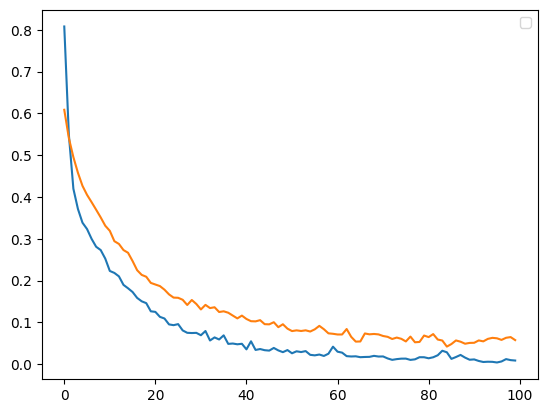

In [10]:
%matplotlib inline
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend()
plt.show()

In [13]:
confusion_matri = confusion_matrix(y_test, model.predict(X_test).round())
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matri)
print(classification_report(y_test, model.predict(X_test).round()))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

